In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import sys, os

sys.path.append('../src/')
sys.path.append('../content/')

import data_utils as du
import numpy as np
from functools import reduce
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import haversine_distances

### DEFINE UTILITIES ###

# Calculate task-agnostic overlap between embeddings
# This basically compares feature similarity structure across examples
# It's based on https://arxiv.org/pdf/1905.00414 and the accompanying demo
# https://colab.research.google.com/github/google-research/google-research/blob/master/representation_similarity/Demo.ipynb
# For now I'll just copy over their utility functions

import numpy as np


def gram_linear(x):
  """Compute Gram (kernel) matrix for a linear kernel.

  Args:
    x: A num_examples x num_features matrix of features.

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  return x.dot(x.T)


def gram_rbf(x, threshold=1.0):
  """Compute Gram (kernel) matrix for an RBF kernel.

  Args:
    x: A num_examples x num_features matrix of features.
    threshold: Fraction of median Euclidean distance to use as RBF kernel
      bandwidth. (This is the heuristic we use in the paper. There are other
      possible ways to set the bandwidth; we didn't try them.)

  Returns:
    A num_examples x num_examples Gram matrix of examples.
  """
  dot_products = x.dot(x.T)
  sq_norms = np.diag(dot_products)
  sq_distances = -2 * dot_products + sq_norms[:, None] + sq_norms[None, :]
  sq_median_distance = np.median(sq_distances)
  return np.exp(-sq_distances / (2 * threshold ** 2 * sq_median_distance))


def center_gram(gram, unbiased=False):
  """Center a symmetric Gram matrix.

  This is equvialent to centering the (possibly infinite-dimensional) features
  induced by the kernel before computing the Gram matrix.

  Args:
    gram: A num_examples x num_examples symmetric matrix.
    unbiased: Whether to adjust the Gram matrix in order to compute an unbiased
      estimate of HSIC. Note that this estimator may be negative.

  Returns:
    A symmetric matrix with centered columns and rows.
  """
  if not np.allclose(gram, gram.T):
    raise ValueError('Input must be a symmetric matrix.')
  gram = gram.copy()

  if unbiased:
    # This formulation of the U-statistic, from Szekely, G. J., & Rizzo, M.
    # L. (2014). Partial distance correlation with methods for dissimilarities.
    # The Annals of Statistics, 42(6), 2382-2412, seems to be more numerically
    # stable than the alternative from Song et al. (2007).
    n = gram.shape[0]
    np.fill_diagonal(gram, 0)
    means = np.sum(gram, 0, dtype=np.float64) / (n - 2)
    means -= np.sum(means) / (2 * (n - 1))
    gram -= means[:, None]
    gram -= means[None, :]
    np.fill_diagonal(gram, 0)
  else:
    means = np.mean(gram, 0, dtype=np.float64)
    means -= np.mean(means) / 2
    gram -= means[:, None]
    gram -= means[None, :]

  return gram


def cka(gram_x, gram_y, debiased=False):
  """Compute CKA.

  Args:
    gram_x: A num_examples x num_examples Gram matrix.
    gram_y: A num_examples x num_examples Gram matrix.
    debiased: Use unbiased estimator of HSIC. CKA may still be biased.

  Returns:
    The value of CKA between X and Y.
  """
  gram_x = center_gram(gram_x, unbiased=debiased)
  gram_y = center_gram(gram_y, unbiased=debiased)

  # Note: To obtain HSIC, this should be divided by (n-1)**2 (biased variant) or
  # n*(n-3) (unbiased variant), but this cancels for CKA.
  scaled_hsic = gram_x.ravel().dot(gram_y.ravel())

  normalization_x = np.linalg.norm(gram_x)
  normalization_y = np.linalg.norm(gram_y)
  return scaled_hsic / (normalization_x * normalization_y)


def _debiased_dot_product_similarity_helper(
        xty, sum_squared_rows_x, sum_squared_rows_y, squared_norm_x, squared_norm_y,
        n):
  """Helper for computing debiased dot product similarity (i.e. linear HSIC)."""
  # This formula can be derived by manipulating the unbiased estimator from
  # Song et al. (2007).
  return (
      xty - n / (n - 2.) * sum_squared_rows_x.dot(sum_squared_rows_y)
      + squared_norm_x * squared_norm_y / ((n - 1) * (n - 2)))


def feature_space_linear_cka(features_x, features_y, debiased=False):
  """Compute CKA with a linear kernel, in feature space.

  This is typically faster than computing the Gram matrix when there are fewer
  features than examples.

  Args:
    features_x: A num_examples x num_features matrix of features.
    features_y: A num_examples x num_features matrix of features.
    debiased: Use unbiased estimator of dot product similarity. CKA may still be
      biased. Note that this estimator may be negative.

  Returns:
    The value of CKA between X and Y.
  """
  features_x = features_x - np.mean(features_x, 0, keepdims=True)
  features_y = features_y - np.mean(features_y, 0, keepdims=True)

  dot_product_similarity = np.linalg.norm(features_x.T.dot(features_y)) ** 2
  normalization_x = np.linalg.norm(features_x.T.dot(features_x))
  normalization_y = np.linalg.norm(features_y.T.dot(features_y))

  if debiased:
    n = features_x.shape[0]
    # Equivalent to np.sum(features_x ** 2, 1) but avoids an intermediate array.
    sum_squared_rows_x = np.einsum('ij,ij->i', features_x, features_x)
    sum_squared_rows_y = np.einsum('ij,ij->i', features_y, features_y)
    squared_norm_x = np.sum(sum_squared_rows_x)
    squared_norm_y = np.sum(sum_squared_rows_y)

    dot_product_similarity = _debiased_dot_product_similarity_helper(
        dot_product_similarity, sum_squared_rows_x, sum_squared_rows_y,
        squared_norm_x, squared_norm_y, n)
    normalization_x = np.sqrt(_debiased_dot_product_similarity_helper(
        normalization_x ** 2, sum_squared_rows_x, sum_squared_rows_x,
        squared_norm_x, squared_norm_x, n))
    normalization_y = np.sqrt(_debiased_dot_product_similarity_helper(
        normalization_y ** 2, sum_squared_rows_y, sum_squared_rows_y,
        squared_norm_y, squared_norm_y, n))

  return dot_product_similarity / (normalization_x * normalization_y)

def cca(features_x, features_y):
  """Compute the mean squared CCA correlation (R^2_{CCA}).

  Args:
    features_x: A num_examples x num_features matrix of features.
    features_y: A num_examples x num_features matrix of features.

  Returns:
    The mean squared CCA correlations between X and Y.
  """
  qx, _ = np.linalg.qr(features_x)  # Or use SVD with full_matrices=False.
  qy, _ = np.linalg.qr(features_y)
  return np.linalg.norm(qx.T.dot(qy)) ** 2 / min(
      features_x.shape[1], features_y.shape[1])

def rsa(features_x, features_y):
   """Only function that's not taken from Kornblith et al.
  Args:
    features_x: A num_examples x num_features matrix of features.
    features_y: A num_examples x num_features matrix of features.

  Returns:
    The similarity-of-similarities, i.e. the correlation between
    the upper triangles of the example x example correlation matrices
    for the both sets of features

   """
   cx = np.corrcoef(features_x)
   cy = np.corrcoef(features_y)
   upper_triangles = np.stack([m[np.triu_indices(features_x.shape[0],1)] for m in [cx, cy]])
   return np.corrcoef(upper_triangles[:, np.sum(np.isnan(upper_triangles),axis=0)==0])[0,1]

### LOAD DATA ###

In [16]:
def cca_weighted(features_x, features_y):
    qx, _ = np.linalg.qr(features_x)
    qy, _ = np.linalg.qr(features_y)
    
    cross = qx.T.dot(qy)
    _, singular_values, _ = np.linalg.svd(cross, full_matrices=False)
    
    correlations = singular_values ** 2          # R² for each CC pair
    weights = correlations / correlations.sum()  # variance-proportional weights
    
    return np.sum(weights * correlations)        # weighted mean R²


In [17]:

### LOAD DATA ###

# Initialise paths
data_folder = '../data/'
list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')

# Set data sources for which I have pixel values
modalities = ['alphaearth', 'tessera', 'satclip', 'geoclip'] 
samples = ['random_sample', 'lc_stratified_sample']
sample_ids = [gdf_points['id'][gdf_points[s]==1].to_numpy() for s in samples]
embeddings = [[du.load_csv_with_points(parent_folder=data_folder, modality=m, sample_type=s) 
               for s in samples] for m in modalities]

# Only included samples that are present across all modalities
common_samples = [[e['id'].to_numpy() for e in emb] for emb in embeddings]
common_samples = [reduce(np.intersect1d, ([s[i] for s in common_samples])) for i in range(len(samples))]
common_embeddings = [[e.set_index("id").loc[inc].reset_index(drop=True).to_numpy() for inc, e in zip(common_samples, emb)] for emb in embeddings]

### CALCULATE OVERLAP ###
# Choose which sample to plot for (s=0: random; s=1: stratified)
s = 0
sim_cka = np.zeros((len(modalities), len(modalities)))
sim_cca = np.zeros((len(modalities), len(modalities)))
sim_rsa = np.zeros((len(modalities), len(modalities)))
sim_cca_weighted = np.zeros((len(modalities), len(modalities)))

# Bit dumb to calculate all entries of symmetric matrices but whatever
for i, e_from in enumerate(common_embeddings):
    for j, e_to in enumerate(common_embeddings):
        sim_cka[i, j] = feature_space_linear_cka(e_from[s], e_to[s])
        sim_cca[i, j] = cca(e_from[s], e_to[s])
        sim_rsa[i, j] = rsa(e_from[s], e_to[s])
        sim_cca_weighted[i, j] = cca_weighted(e_from[s], e_to[s])
        print(f'Finished {i}, {j}')


Sample random_sample has 10000 data points out of 18973.
Sample lc_stratified_sample has 10000 data points out of 18973.
Number of samples: 18973
Finished 0, 0


/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neureo/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Finished 0, 1
Finished 0, 2
Finished 0, 3
Finished 1, 0
Finished 1, 1
Finished 1, 2
Finished 1, 3
Finished 2, 0
Finished 2, 1
Finished 2, 2
Finished 2, 3
Finished 3, 0
Finished 3, 1
Finished 3, 2
Finished 3, 3


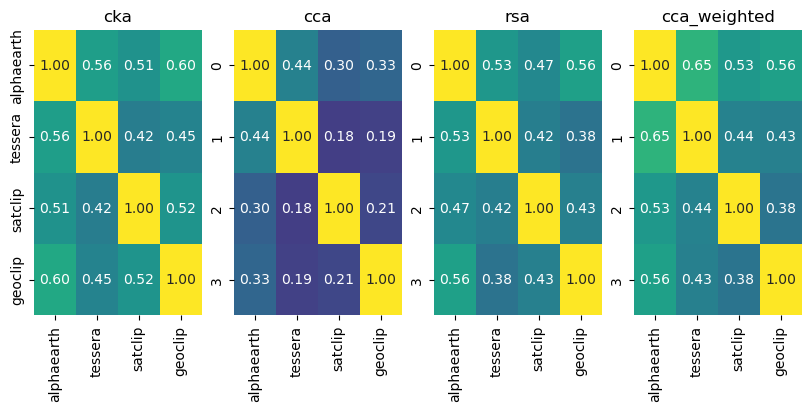

In [12]:
import seaborn as sns
# Plot results
fig, axs = plt.subplots(1, 4, figsize=(8, 4), constrained_layout=True)
ims = []
for col, (ax, data, method) in enumerate(zip(
    axs,
    [sim_cka, sim_cca, sim_rsa, sim_cca_weighted],
    ['cka', 'cca', 'rsa', 'cca_weighted']
)):
    # im = ax.imshow(data, vmin=0, vmax=1)
    sns.heatmap(data, vmin=0, vmax=1, annot=True, fmt=".2f", cmap='viridis', ax=ax, cbar=False)
    # ims.append(im)
    ax.set_title(method)
    ax.set_xticks(np.arange(4) + 0.5)
    ax.set_xticklabels(modalities, rotation=90)
    if col == 0:
        ax.set_yticks(np.arange(4) + 0.5)
        ax.set_yticklabels(modalities)
# fig.colorbar(ims[0], ax=axs, location='right', shrink=0.5)

In [18]:
dict_data = {x: [] for x in ['pair', 'cka', 'cca', 'rsa', 'cca_weighted']}
for i in range(len(modalities)):
    for j in range(i+1, len(modalities)):
        dict_data['pair'].append(f'{modalities[i]}-{modalities[j]}')
        dict_data['cka'].append(sim_cka[i, j])
        dict_data['cca'].append(sim_cca[i, j])
        dict_data['rsa'].append(sim_rsa[i, j])
        dict_data['cca_weighted'].append(sim_cca_weighted[i, j])

import pandas as pd
df_results = pd.DataFrame(dict_data)
# df_results.to_csv('../outputs/task_agnostic_overlap.csv', index=False)